In [ ]:
# Install pysynphot in the Colab environment
# =================================================================
# 1. INSTALLATION & ENVIRONMENT SETUP
# =================================================================
!pip install matplotlib scipy h5py
!pip install "numpy<2.0" pysynphot astropy sh

In [ ]:
# =================================================================
# 2. IMPORTS
# =================================================================
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.ticker import LogFormatterExponent
import matplotlib.ticker as mticker
from numpy import unravel_index
import astropy.units as u
import math
from IPython.display import clear_output
import time
from scipy.ndimage import rotate
from scipy.interpolate import RegularGridInterpolator
import h5py
from pathlib import Path
from matplotlib.patches import Circle
from importlib import reload
import pysynphot
from google.colab import drive
import os

# Mount Google Drive
drive.mount('/content/drive')

/usr/local/lib/python3.12/dist-packages/pysynphot/locations.py:46: UserWarning: PYSYN_CDBS is undefined; functionality will be SEVERELY crippled.
  warnings.warn("PYSYN_CDBS is undefined; functionality will be SEVERELY "
/usr/local/lib/python3.12/dist-packages/pysynphot/locations.py:345: UserWarning: Extinction files not found in extinction
  warnings.warn('Extinction files not found in %s' % (extdir, ))


Mounted at /content/drive


In [ ]:
# =================================================================
# 3. FILE PATHS & DATA LOADING
# =================================================================
# Google top level drive dir
drive_dir = "/content/drive/MyDrive/"
diskmodel_dir = 'Roman_winter_school/Dust_grain_sizes/SED'
sed_files=['sed_0.01micron.fits','sed_0.1micron.fits','sed_1micron.fits','sed_10micron.fits','sed_100micron.fits','sed_1000micron.fits','sed_1-1000micron.fits']
# Disk Model Path
diskmodel_path = os.path.join(drive_dir,diskmodel_dir)


In this part of the notebook we will look at how the SED changes for different dust grain sizes

In [ ]:
## function for plotting SED for different size dust grains

def plot_grain_sed(grain_size, base_path):
    """
    grain_size: float/str (e.g., 0.01 or 0.1)
    base_path: The path to the directory containing 'data_th'
    """

    # Construct the file path
    # Colab paths are case-sensitive!
    file_path = os.path.join(base_path, f'sed_{grain_size}micron.fits')

    if not os.path.exists(file_path):
        print(f"❌ File not found: {file_path}")
        return

    # 1. Open FITS and extract data
    with fits.open(file_path) as hdul:
        wav = hdul[1].data
        # Flattening to ensure 1D arrays for Pysynphot
        modelt_flux = hdul[0].data[0].flatten()
        star_flux   = hdul[0].data[1].flatten()
        sst_flux    = hdul[0].data[2].flatten()
        dth_flux    = hdul[0].data[3].flatten()

    # 2. Create Pysynphot Spectra
    # We use raw strings r'' to avoid backslash issues
    modeltotal = pysynphot.ArraySpectrum(wav, modelt_flux, name='total', fluxunits='flam', waveunits='microns')
    star       = pysynphot.ArraySpectrum(wav, star_flux,   name='star',  fluxunits='flam', waveunits='microns')
    scat_light = pysynphot.ArraySpectrum(wav, sst_flux,    name='scat',  fluxunits='flam', waveunits='microns')
    dir_th     = pysynphot.ArraySpectrum(wav, dth_flux,    name='dth',   fluxunits='flam', waveunits='microns')

    # 3. Unit Conversion (mJy logic)
    c = 2.99792e14 # microns to Hz factor

    def to_mjy(spec):
        return 1e26 * spec.flux * spec.wave * 1000 / c

    mt_jy = to_mjy(modeltotal)
    st_jy = to_mjy(star)
    scat_jy = to_mjy(scat_light)
    dth_jy = to_mjy(dir_th)

    # 4. Plotting
    fig, ax = plt.subplots(figsize=(5, 5))

    # Plot data
    ax.loglog(wav, mt_jy,   '-',  color='red',    label='Total Model', lw=2)
    ax.loglog(wav, st_jy,   '--', color='blue',   label='Star')
    ax.loglog(wav, scat_jy, '--', color='green',  label='Scattered light')
    ax.loglog(wav, dth_jy,  '--', color='cyan',   label='Thermal Emission')

    # Formatting
    ax.yaxis.set_ticks_position('both')
    ax.xaxis.set_ticks_position('both')
    ax.tick_params(which='both', direction='in', width=0.7, labelsize=14)
    ax.minorticks_on()

    ax.set_ylim(1e-1, 4e5)
    ax.set_xlim(0.1, 3000)

    # Using LaTeX for cleaner math symbols
    ax.set_ylabel(r'$F_\lambda$ (mJy)', fontsize=16)
    ax.set_xlabel(r'Wavelength ($\mu$m)', fontsize=16)
    ax.set_title(f'HR4796A - {grain_size} $\mu$m grains', fontsize=18)

    #ax.legend(loc='upper right', fontsize=10, frameon=True)

    # Force "plain" numbers on x-axis (0.1, 1, 10 instead of 10^n)
    ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
    ax.xaxis.get_major_formatter().set_scientific(False)

    plt.tight_layout()
    plt.show()

    return

<>:65: SyntaxWarning: invalid escape sequence '\m'
<>:65: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_687/3648349296.py:65: SyntaxWarning: invalid escape sequence '\m'
  ax.set_title(f'HR4796A - {grain_size} $\mu$m grains', fontsize=18)


Let's plot the SED for 0.01 micron size dust grains

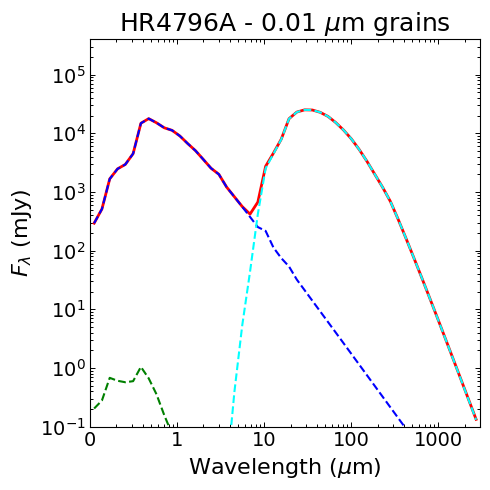

In [ ]:
plot_grain_sed('0.01', diskmodel_path)

Let's plot the SED for 1 micron size dust grains

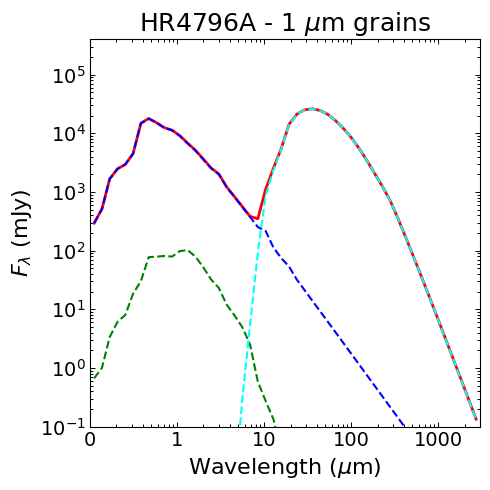

In [ ]:
plot_grain_sed('1', diskmodel_path)

Let's plot the SED for 100 micron size dust grains

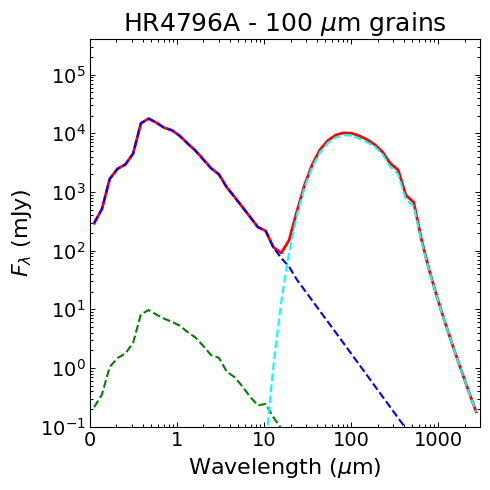

In [ ]:
plot_grain_sed('100', diskmodel_path)

Let's plot the SED for 1000 micron size dust grains

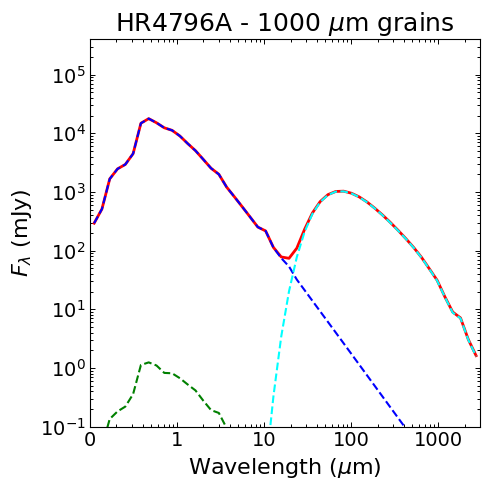

In [ ]:
plot_grain_sed('1000', diskmodel_path)

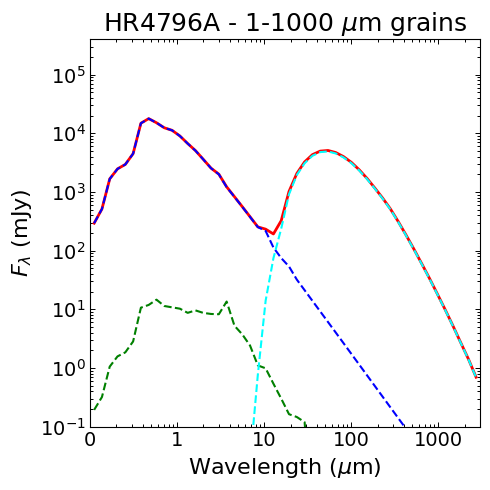

In [ ]:
plot_grain_sed('1-1000', diskmodel_path)

Now we will look at the scattered light and  thermal emission images for the same dust grain sizes variation


In [ ]:
def plot_dust_images(grain_size, base_path, wav_val=0.575):
    """
    Plots Scattered Light and Thermal Emission side-by-side.
    grain_size: string or float (e.g., '0.1', 1000, or '0.01')
    base_path: The folder containing your FITS files
    """

    # 1. Construct the filename
    # Example: grainsize_0.1micron_wav_0.575micron.fits
    fits_file = f"grainsize_{grain_size}micron_wav_{wav_val}micron.fits"
    file_path = os.path.join(base_path, fits_file)

    if not os.path.exists(file_path):
        print(f"❌ File not found: {file_path}")
        return

    # 2. Load and process data
    with fits.open(file_path) as hdul:
        # Reshaping based on your px=256, py=256
        px, py = 256, 256
        scattered_light = np.reshape(hdul[0].data[5], (px, py))
        thermal_emission = np.reshape(hdul[0].data[6], (px, py))

    # 3. psf scale
    psf_scale = 0.2184  # arcsecs/pixel
    sq_as_per_pix = psf_scale**2

    c=2.99792*10**14
    jy=10**26

    sst_jy=(scattered_light/c)*(wav_val*jy)
    dth_jy=(thermal_emission/c)*(wav_val*jy)

    # Define the 100x100 sub-region (centered at 128)
    crop = 50
    center = 128
    extent_val = crop * psf_scale
    # extent = [left, right, bottom, top]
    img_extent = [-extent_val, extent_val, -extent_val, extent_val]

    # 4. Plotting
    fig, axes = plt.subplots(1, 2, figsize=(8, 4), dpi=100)

    # Data and Subplot Titles
    data_sources = [sst_jy.astype(np.float64), dth_jy.astype(np.float64)]
    subplot_titles = ['Scattered Light', 'Thermal Emission']

    for i, ax in enumerate(axes):
        # Slicing the 100x100 center
        img_slice = data_sources[i][center-crop : center+crop, center-crop : center+crop]

        # Conversion to mJy/arcsec^2
        img_to_plot = (img_slice / sq_as_per_pix) * 1000

        im = ax.imshow(img_to_plot, cmap='gnuplot', extent=img_extent, origin='lower')

        ax.invert_yaxis()
        ax.set_ylabel('y [arcsec]')
        ax.set_xlabel('x [arcsec]')

        # Setting the subplot-specific title
        ax.set_title(subplot_titles[i], fontsize=14)

        cb = plt.colorbar(im, ax=ax, orientation='vertical', shrink=0.75)
        cb.set_label("$mJy/arcsec^2$")

    # 5. The Common Main Title
    # Combining the wavelength and grain size into one big header
    main_title = rf'$\lambda={wav_val}\mu m$, Dust grain size = {grain_size}$\mu m$'
    fig.suptitle(main_title, fontsize=18, y=0.98)

    # Adjust layout to prevent title/label overlap
    fig.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    return

Now we will look at the scattered light and thermal emission images for the same dust grain sizes variation at 0.575 microns wavelength

In [ ]:
diskimage_dir = 'Roman_winter_school/Dust_grain_sizes/Images/0.575micron/'
diskmodel_path = os.path.join(drive_dir,diskimage_dir)

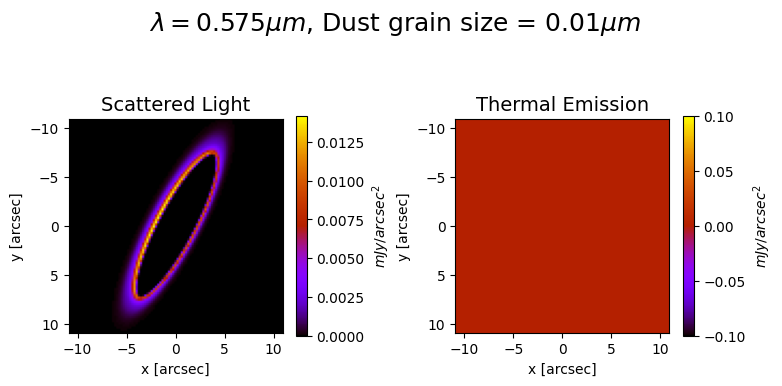

In [ ]:
#plot_dust_images(grain_size, base_path, wav_val=0.575)
plot_dust_images(0.01, diskmodel_path, wav_val=0.575)

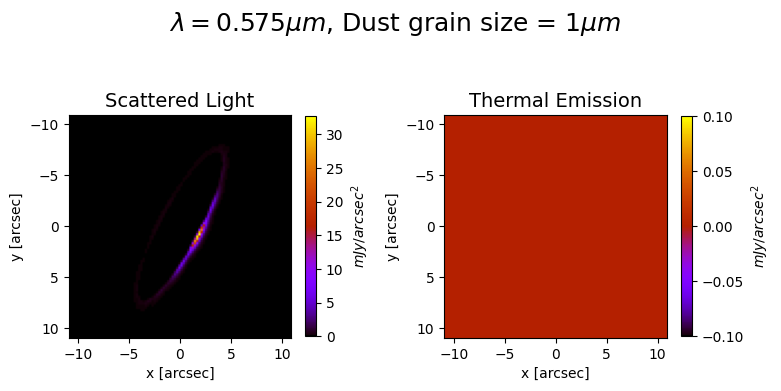

In [ ]:
plot_dust_images(1, diskmodel_path, wav_val=0.575)

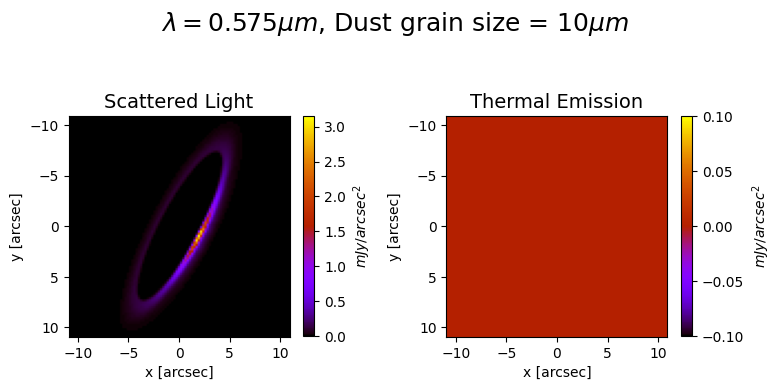

In [ ]:
plot_dust_images(10, diskmodel_path, wav_val=0.575)

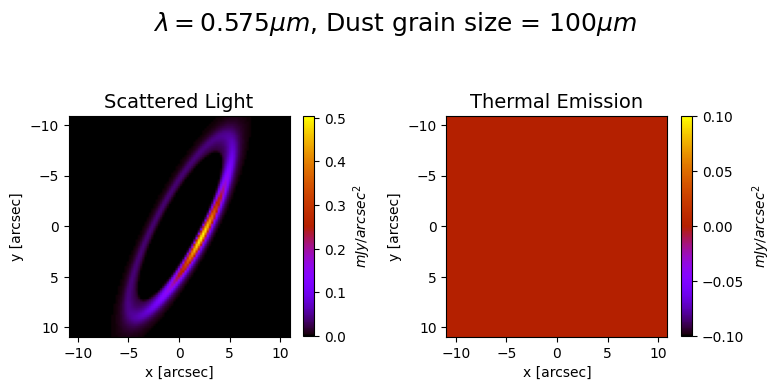

In [ ]:
plot_dust_images(100, diskmodel_path, wav_val=0.575)

In [ ]:
plot_dust_images(1000, diskmodel_path, wav_val=0.575)

Now we will look at the scattered light and thermal emission images for the same dust grain sizes variation at 100 microns wavelength

In [ ]:
diskimage_dir = 'Roman_winter_school/Dust_grain_sizes/Images/100micron/'
diskmodel_path = os.path.join(drive_dir,diskimage_dir)

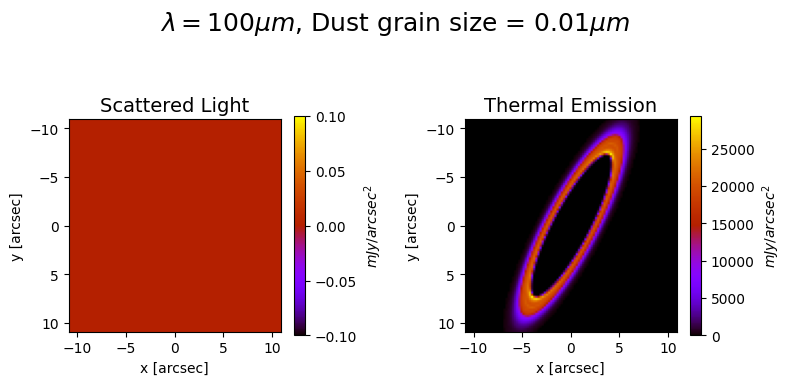

In [ ]:
plot_dust_images(0.01, diskmodel_path, wav_val=100)

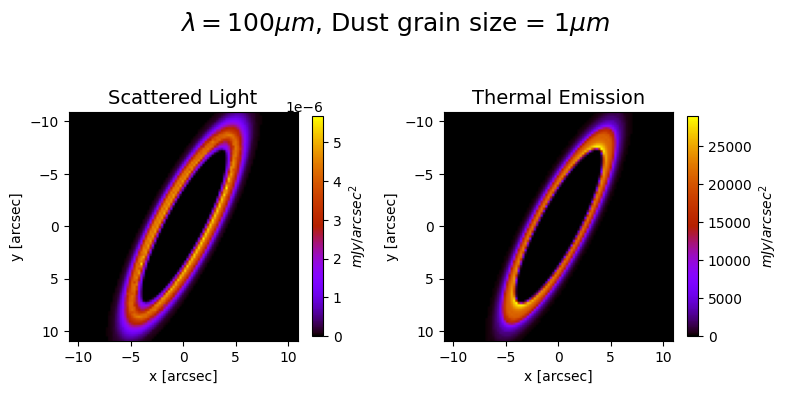

In [ ]:
plot_dust_images(1, diskmodel_path, wav_val=100)

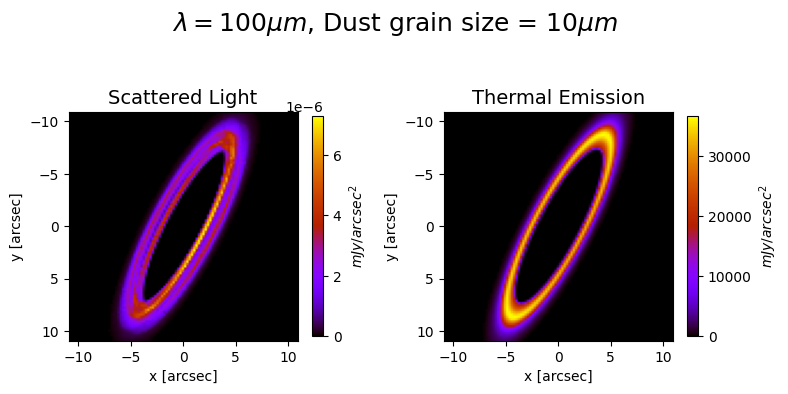

In [ ]:
plot_dust_images(10, diskmodel_path, wav_val=100)

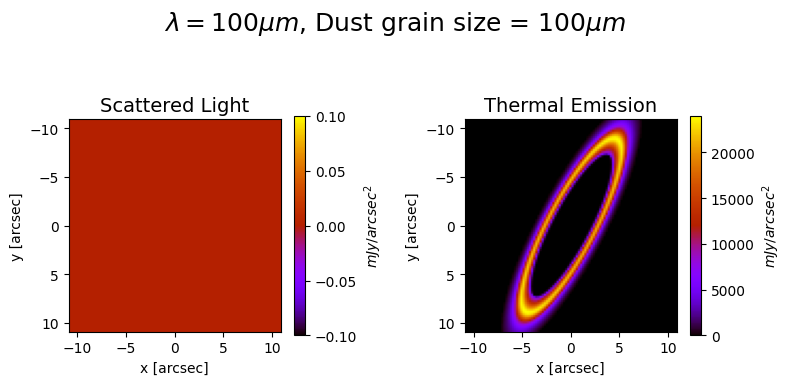

In [ ]:
plot_dust_images(100, diskmodel_path, wav_val=100)

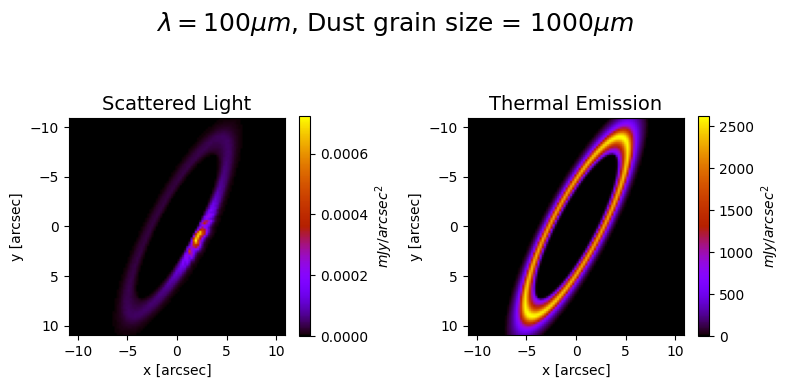

In [ ]:
plot_dust_images(1000, diskmodel_path, wav_val=100)